# Notebook 06: Calibration analysis (SQ2)

Research Sub-Question 2: Is cross-population calibration directionally asymmetric?

Metrics: Standard Expected Calibration Error (ECE), Adaptive Equal-Frequency ECE, Maximum Calibration Error (MCE), Brier Score, and reliability diagrams, evaluated before and after temperature scaling.

Leakage Safeguard:
- The temperature parameter (T) is fitted strictly on each run's in-fold
- validation split, NEVER on the cross-population evaluation targets.

## 1. Setup

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

import sys
from pathlib import Path

REPO_ON_DRIVE = "/content/drive/MyDrive/crosspop-cxr-asymmetry"
for candidate in [REPO_ON_DRIVE, "..", "."]:
    p = Path(candidate).resolve()
    if (p / "config.py").exists():
        sys.path.insert(0, str(p))
        break

import importlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import config
from src import splits as SP
from src import datasets as DS
from src import models as M
from src import inference as INF
from src import metrics as MET
from src import stats as ST
from src import results as RES

for mod in (config, SP, DS, M, INF, MET, ST, RES):
    importlib.reload(mod)

config.ensure_output_dirs()
config.set_plot_style()

device = config.get_device()


Mounted at /content/drive
Compute Device: GPU (Tesla T4)


In [ ]:
manifest = pd.read_csv(config.RESULTS_DIR / "manifests" / "splits_all.csv")
tf_eval = DS.build_transforms(
    config.IMAGE_SIZE,
    config.IMAGENET_MEAN,
    config.IMAGENET_STD,
    train=False
)

meta, arrays = RES.load_predictions(config.RESULTS_DIR / "predictions")
print(f"Loaded {len(meta)} prediction runs from disk.")


Loaded 48 prediction runs from disk.


## 2. Fit Temperature In-Fold and Apply to Target Logits

In [ ]:
def get_val_dataset_for_run(info):
    """Retrieve or reconstruct the in-fold validation dataset for a specific run."""
    seed = info["seed"]
    direction = info["direction"]

    if direction == "N2K":
        fold = info["fold"]
        base_rows = manifest[
            (manifest.dataset == "togunwa") &
            (manifest.direction == "N2K") &
            (manifest.seed.astype(str) == str(seed)) &
            (manifest.fold == fold) &
            (manifest.split == "val")
        ]
        rows = base_rows[["path", "label"]]
    else:
        size = info["size"]
        all_rows = manifest[
            (manifest.dataset == "kermany") &
            (manifest.split == "train") &
            (manifest["size"] == size) &
            (manifest.seed.astype(str) == str(seed))
        ]
        records = all_rows[["path", "label", "class"]].to_dict("records")
        val_records, _ = SP.stratified_holdout(records, round(len(records) * 0.2), seed)
        rows = pd.DataFrame(val_records)[["path", "label"]]

    ds = DS.CXRDataset(rows.reset_index(drop=True), tf_eval)
    return ds, len(rows)


In [ ]:
records = []

print("Fitting temperature parameters on in-fold validation splits...")

for stem, entry in arrays.items():
    info = RES.parse_run_id(stem)
    y_true = entry["y_true"]
    target_logits = entry["logits"]

    ckpt_path = config.CHECKPOINTS_DIR / f"{stem}.pth"
    val_ds, n_val = get_val_dataset_for_run(info)

    # Load model and compute in-fold validation logits
    model = M.build_model(info["arch"], pretrained=False)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

    val_out = INF.predict(model, val_ds, device, batch_size=32, num_workers=2)

    # Fit temperature parameter on validation set only
    temperature = INF.fit_temperature(val_out["logits"], val_out["y_true"])

    # Apply fitted temperature to evaluation target logits
    raw_prob = entry["y_prob"]
    scaled_logits = target_logits / temperature
    calibrated_prob = np.exp(scaled_logits[:, 1]) / np.exp(scaled_logits).sum(axis=1)

    # Store calibrated probabilities for downstream pooling
    entry["cal"] = calibrated_prob

    records.append({
        "arch": info["arch"],
        "direction": info["direction"],
        "size": info.get("size"),
        "seed": info["seed"],
        "fold": info.get("fold"),
        "temperature": round(temperature, 3),
        "ece_raw": MET.expected_calibration_error(y_true, raw_prob, config.ECE_N_BINS),
        "ece_cal": MET.expected_calibration_error(y_true, calibrated_prob, config.ECE_N_BINS),
        "ece_adaptive_raw": MET.adaptive_calibration_error(y_true, raw_prob, config.ECE_N_BINS),
        "ece_adaptive_cal": MET.adaptive_calibration_error(y_true, calibrated_prob, config.ECE_N_BINS),
        "mce_raw": MET.maximum_calibration_error(y_true, raw_prob, config.ECE_N_BINS),
        "brier_raw": MET.brier_score(y_true, raw_prob),
        "brier_cal": MET.brier_score(y_true, calibrated_prob)
    })

cal_df = pd.DataFrame(records)

print("\n--- Per-Run Calibration Summary (First 8 Runs) ---")
print(cal_df.head(8).to_string(index=False))

cal_csv_path = config.RESULTS_DIR / "06_calibration_per_run.csv"
cal_df.to_csv(cal_csv_path, index=False)
print(f"Saved per-run calibration data to {cal_csv_path.name}")


Fitting temperature parameters on in-fold validation splits...

--- Per-Run Calibration Summary (First 8 Runs) ---
           arch direction  size  seed  fold  temperature  ece_raw  ece_cal  ece_adaptive_raw  ece_adaptive_cal  mce_raw  brier_raw  brier_cal
efficientnet_b0       K2N   100    42   NaN        0.909 0.364981 0.394851          0.389316          0.397026 0.909333   0.337968   0.346454
efficientnet_b0       K2N   100    43   NaN        0.397 0.381695 0.414523          0.351683          0.413097 0.652032   0.322027   0.383861
efficientnet_b0       K2N   100    44   NaN        1.459 0.250058 0.278913          0.243423          0.243602 0.744719   0.228231   0.213353
efficientnet_b0       K2N   190    42   NaN        0.823 0.382534 0.382083          0.444705          0.453367 0.920335   0.352880   0.369491
efficientnet_b0       K2N   190    43   NaN        0.218 0.358428 0.429599          0.393916          0.399222 0.847077   0.331326   0.415688
efficientnet_b0       K2N   190  

## 3. Per-Run Calibration Error Distribution

In [ ]:
print("\n--- Raw ECE (Equal-Width) by Direction and Seed ---")
print(cal_df.groupby(["direction", "seed"])["ece_raw"].agg(["mean", "min", "max", "count"]).round(3).to_string())

print("\n--- Raw ECE (Equal-Width) by Direction and Sample Size ---")
print(cal_df.groupby(["direction", "size"])["ece_raw"].agg(["mean", "std", "min", "max"]).round(3).to_string())

print("\n--- Temperature Scaling Effect (Mean ECE Raw -> Calibrated) ---")
print(cal_df.groupby("direction")[["ece_raw", "ece_cal", "ece_adaptive_raw", "ece_adaptive_cal"]].mean().round(3).to_string())



--- Raw ECE (Equal-Width) by Direction and Seed ---
                 mean    min    max  count
direction seed                            
K2N       42    0.378  0.341  0.416      6
          43    0.363  0.314  0.435      6
          44    0.273  0.220  0.340      6
N2K       42    0.173  0.046  0.267     10
          43    0.169  0.062  0.377     10
          44    0.175  0.085  0.295     10

--- Raw ECE (Equal-Width) by Direction and Sample Size ---
                 mean    std    min    max
direction size                            
K2N       50    0.316  0.050  0.220  0.354
          100   0.363  0.065  0.250  0.435
          190   0.334  0.067  0.247  0.416
N2K       190   0.172  0.078  0.046  0.377

--- Temperature Scaling Effect (Mean ECE Raw -> Calibrated) ---
           ece_raw  ece_cal  ece_adaptive_raw  ece_adaptive_cal
direction                                                      
K2N          0.338    0.367             0.343             0.370
N2K          0.172    0.160 

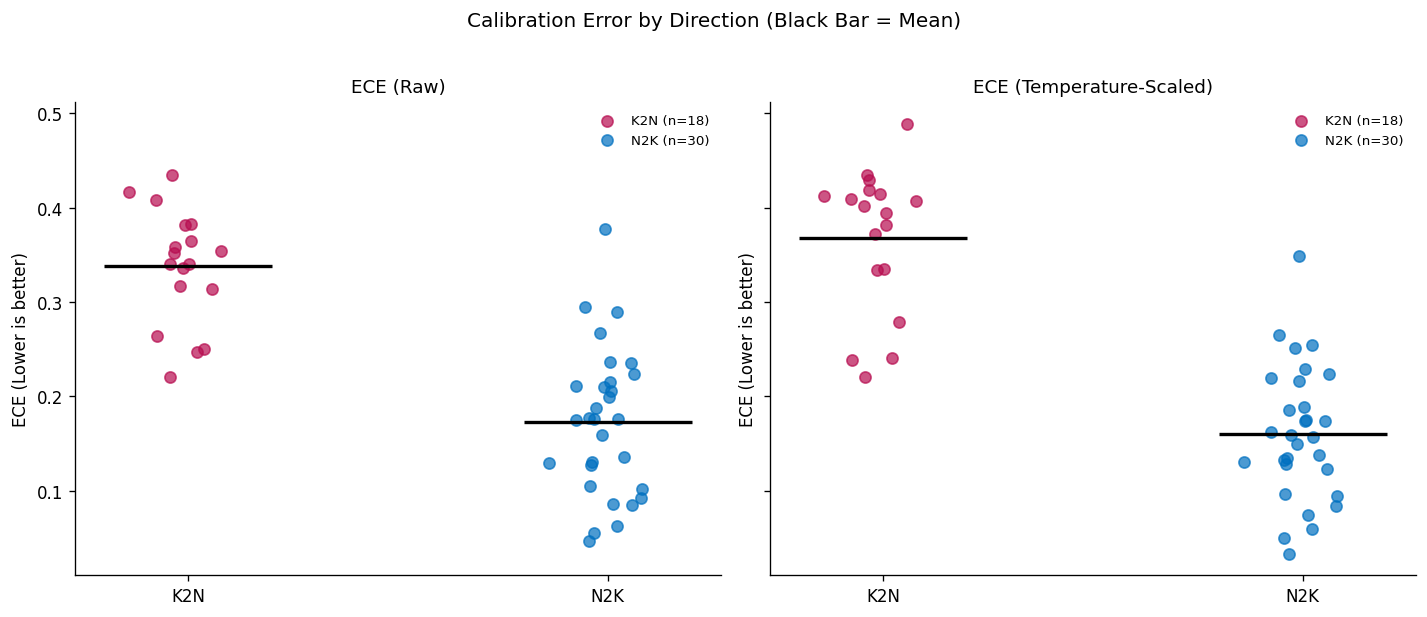

Saved figure to 06_ece_by_direction.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

plots_config = [
    (axes[0], "ece_raw", "ECE (Raw)"),
    (axes[1], "ece_cal", "ECE (Temperature-Scaled)")
]

for ax, col, title in plots_config:
    for i, direction in enumerate(config.DIRECTIONS):
        sub_df = cal_df[cal_df.direction == direction]
        x_jitter = np.random.default_rng(0).normal(i, 0.06, len(sub_df))

        ax.scatter(
            x_jitter,
            sub_df[col],
            alpha=0.7,
            s=45,
            color=[config.BRAND["C1"], config.BRAND["C3"]][i],
            label=f"{direction} (n={len(sub_df)})"
        )
        ax.hlines(sub_df[col].mean(), i - 0.2, i + 0.2, color="black", linewidth=2)

    ax.set_xticks(range(len(config.DIRECTIONS)))
    ax.set_xticklabels(config.DIRECTIONS)
    ax.set_title(title)
    ax.set_ylabel("ECE (Lower is better)")
    ax.legend(fontsize=8)

fig.suptitle("Calibration Error by Direction (Black Bar = Mean)", y=1.02)
fig.tight_layout()

fig_out_path = config.FIGURES_DIR / "06_ece_by_direction.png"
fig.savefig(fig_out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved figure to {fig_out_path.name}")


## 4. Pooled Calibration Analysis with Bootstrap CIs

In [ ]:
ece_metric_fn = lambda a, b: MET.expected_calibration_error(a, b, config.ECE_N_BINS)
ece_adaptive_metric_fn = lambda a, b: MET.adaptive_calibration_error(a, b, config.ECE_N_BINS)

pooled_rows = []

for direction in config.DIRECTIONS:
    for probs_type, label in [("y_prob", "raw"), ("cal", "calibrated")]:
        y_true_pooled, y_prob_pooled = RES.pool_predictions(
            meta,
            arrays,
            direction=direction,
            which=probs_type
        )

        # Standard Equal-Width ECE
        ece_pt, ece_lo, ece_hi, _ = ST.bootstrap_ci(
            y_true_pooled,
            y_prob_pooled,
            ece_metric_fn,
            n_boot=config.BOOTSTRAP_N,
            ci=config.BOOTSTRAP_CI,
            seed=config.SEED
        )

        # Adaptive Equal-Frequency ECE
        adp_pt, adp_lo, adp_hi, _ = ST.bootstrap_ci(
            y_true_pooled,
            y_prob_pooled,
            ece_adaptive_metric_fn,
            n_boot=config.BOOTSTRAP_N,
            ci=config.BOOTSTRAP_CI,
            seed=config.SEED
        )

        pooled_rows.append({
            "direction": direction,
            "probs": label,
            "n_pooled": len(y_true_pooled),
            "ece": round(ece_pt, 3),
            "ece_lo": round(ece_lo, 3),
            "ece_hi": round(ece_hi, 3),
            "ece_adaptive": round(adp_pt, 3),
            "ece_adaptive_lo": round(adp_lo, 3),
            "ece_adaptive_hi": round(adp_hi, 3),
        })

pooled_cal_df = pd.DataFrame(pooled_rows)
print("\n--- Pooled Calibration by Direction (95% Bootstrap CI) ---")
print(pooled_cal_df.to_string(index=False))

pooled_csv_path = config.RESULTS_DIR / "06_pooled_calibration.csv"
pooled_cal_df.to_csv(pooled_csv_path, index=False)



--- Pooled Calibration by Direction (95% Bootstrap CI) ---
direction      probs  n_pooled   ece  ece_lo  ece_hi  ece_adaptive  ece_adaptive_lo  ece_adaptive_hi
      K2N        raw       540 0.249   0.215   0.291         0.238            0.205            0.283
      K2N calibrated       540 0.304   0.271   0.349         0.290            0.258            0.336
      N2K        raw     18720 0.143   0.140   0.147         0.143            0.140            0.147
      N2K calibrated     18720 0.139   0.136   0.142         0.139            0.136            0.142


In [ ]:
def get_bootstrap_distributions(direction, probs_type):
    """Retrieve bootstrap distribution vectors for both standard and adaptive ECE."""
    y_true_pooled, y_prob_pooled = RES.pool_predictions(
        meta,
        arrays,
        direction=direction,
        which=probs_type
    )
    _, _, _, boot_std = ST.bootstrap_ci(
        y_true_pooled,
        y_prob_pooled,
        ece_metric_fn,
        n_boot=config.BOOTSTRAP_N,
        seed=config.SEED
    )
    _, _, _, boot_adp = ST.bootstrap_ci(
        y_true_pooled,
        y_prob_pooled,
        ece_adaptive_metric_fn,
        n_boot=config.BOOTSTRAP_N,
        seed=config.SEED
    )
    return boot_std, boot_adp

boot_k2n_raw_std, boot_k2n_raw_adp = get_bootstrap_distributions("K2N", "y_prob")
boot_n2k_raw_std, boot_n2k_raw_adp = get_bootstrap_distributions("N2K", "y_prob")

# Standardized N2K - K2N convention matching Notebooks 05 and 08
diff_std, diff_lo_std, diff_hi_std = ST.bootstrap_diff_ci(boot_n2k_raw_std, boot_k2n_raw_std, ci=config.BOOTSTRAP_CI)
diff_adp, diff_lo_adp, diff_hi_adp = ST.bootstrap_diff_ci(boot_n2k_raw_adp, boot_k2n_raw_adp, ci=config.BOOTSTRAP_CI)

print("\n--- Raw ECE Direction Contrast (N2K - K2N) ---")
print(f"  Standard Equal-Width ECE Diff: {diff_std:+.3f}  95% CI [{diff_lo_std:+.3f}, {diff_hi_std:+.3f}]")
print(f"  Adaptive Equal-Freq ECE Diff:  {diff_adp:+.3f}  95% CI [{diff_lo_adp:+.3f}, {diff_hi_adp:+.3f}]")

calibration_asymmetry_status = (
    "CI excludes 0: K2N reliably worse-calibrated than N2K at the 95% level under both metrics"
    if ((diff_hi_std < 0 or diff_lo_std > 0) and (diff_hi_adp < 0 or diff_lo_adp > 0))
    else "CI includes 0: no reliable calibration asymmetry"
)
print(f"  Conclusion -> {calibration_asymmetry_status}")



--- Raw ECE Direction Contrast (N2K - K2N) ---
  Standard Equal-Width ECE Diff: -0.110  95% CI [-0.148, -0.072]
  Adaptive Equal-Freq ECE Diff:  -0.100  95% CI [-0.139, -0.062]
  Conclusion -> CI excludes 0: K2N reliably worse-calibrated than N2K at the 95% level under both metrics


## 5. Reliability Diagrams (Pooled by Direction)

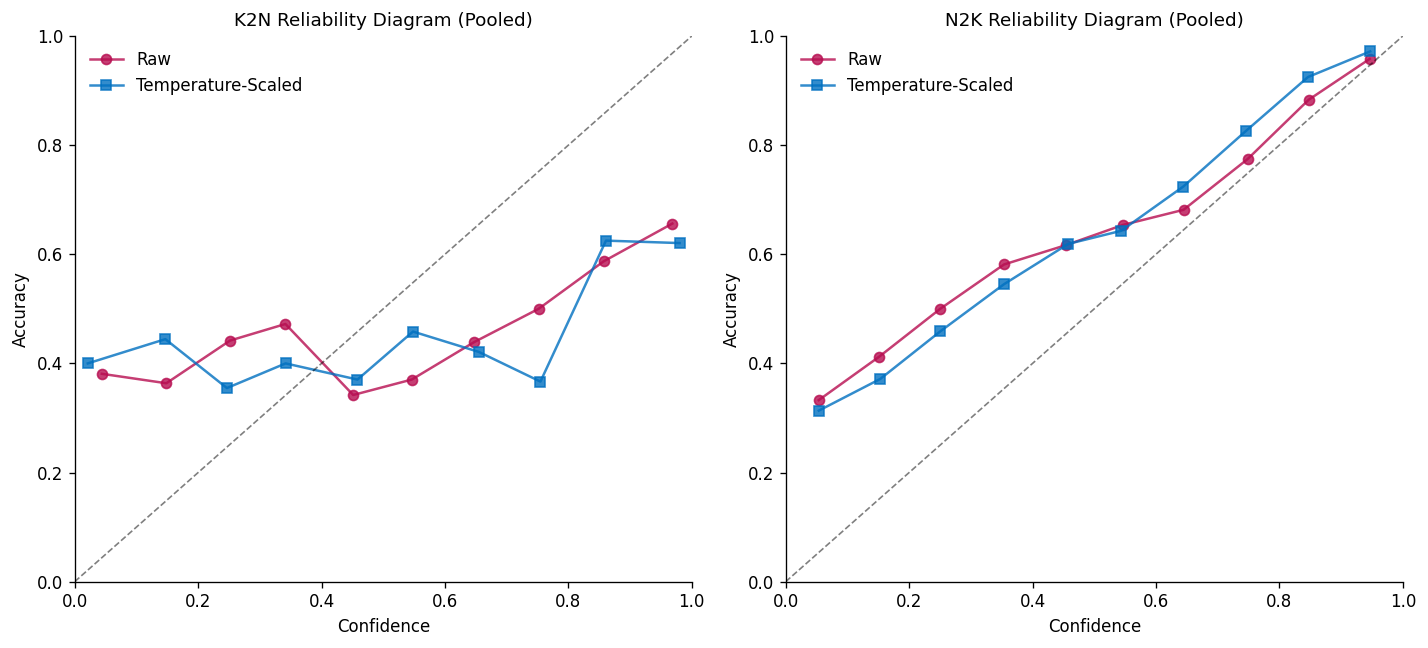

Saved figure to 06_reliability.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, direction in zip(axes, config.DIRECTIONS):
    for probs_type, marker_style in [("y_prob", "o"), ("cal", "s")]:
        y_true_pooled, y_prob_pooled = RES.pool_predictions(
            meta,
            arrays,
            direction=direction,
            which=probs_type
        )
        confidences, accuracies = MET.reliability_curve(y_true_pooled, y_prob_pooled, n_bins=10)

        label_text = "Raw" if probs_type == "y_prob" else "Temperature-Scaled"
        plot_color = config.BRAND["C1"] if probs_type == "y_prob" else config.BRAND["C3"]
        ax.plot(confidences, accuracies, marker=marker_style, color=plot_color, label=label_text, alpha=0.8)

    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
    ax.set_title(f"{direction} Reliability Diagram (Pooled)")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

fig.tight_layout()

rel_fig_out_path = config.FIGURES_DIR / "06_reliability.png"
fig.savefig(rel_fig_out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved figure to {rel_fig_out_path.name}")


**Next:** notebook 07 (size interaction, SQ3).